In [1]:
from statsmodels.genmod.families.links import *
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cskpd_new_update import *
import matplotlib.colors as mcolors

In [2]:
g = Logit()
C_true = np.load("Examples/circles.npy")
np.random.seed(539)
## image shape
img_shape_m,img_shape_n,img_shape_d = 128,128,1
## sample size 
N = 1000
## noise level
sigma = 3
epsilon = np.random.normal(0,1,N) * sigma
X = np.random.normal(0,1,[N, img_shape_m, img_shape_n, img_shape_d]).squeeze()
if isinstance(g, Identity):
    Y = g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon)
elif isinstance(g, Logit):
    Y = np.random.binomial(1,g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon))
else:
    raise NotImplementedError

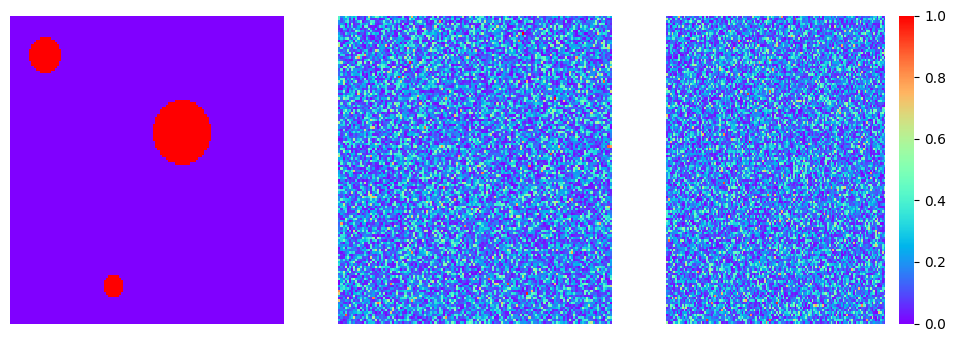

In [3]:
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
plt.figure(figsize= (12,4))
ax = plt.subplot(1,3,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,2)
sns.heatmap(fun_normalization(X[np.argmax(Y)]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,3,3)
sns.heatmap(fun_normalization(X[np.argmin(Y)]),cmap = "rainbow",cbar = True)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [4]:
p_list = [[16,16],[32,32]]
lam = [2**i for i in range(-2,1)]
test_model = CSKPD(p_list[1],lama=lam[0],lamb=lam[0],R=1,g=g,n_cores = 1,max_iter = 3,print_iter = 5)
test_model.fit(X,Y,tol=1E-3)
C_mbic = test_model.score['C']

In [5]:
params = {
    'p': p_list,
    'lama': lam,
    'lamb': lam,
    'g': g,
    # 'R': 3,
    'max_iter': 10
}
best_fit_model, all_models = best_fit(X, Y, parameters_dict=params)

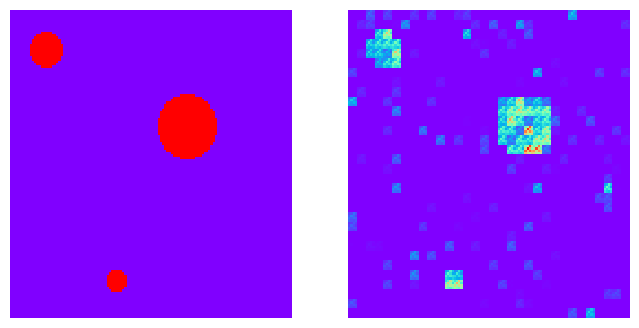

In [6]:
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
plt.figure(figsize= (8,4))
ax = plt.subplot(1,2,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax = plt.subplot(1,2,2)
sns.heatmap(fun_normalization(best_fit_model.score['C']),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])

plt.show()

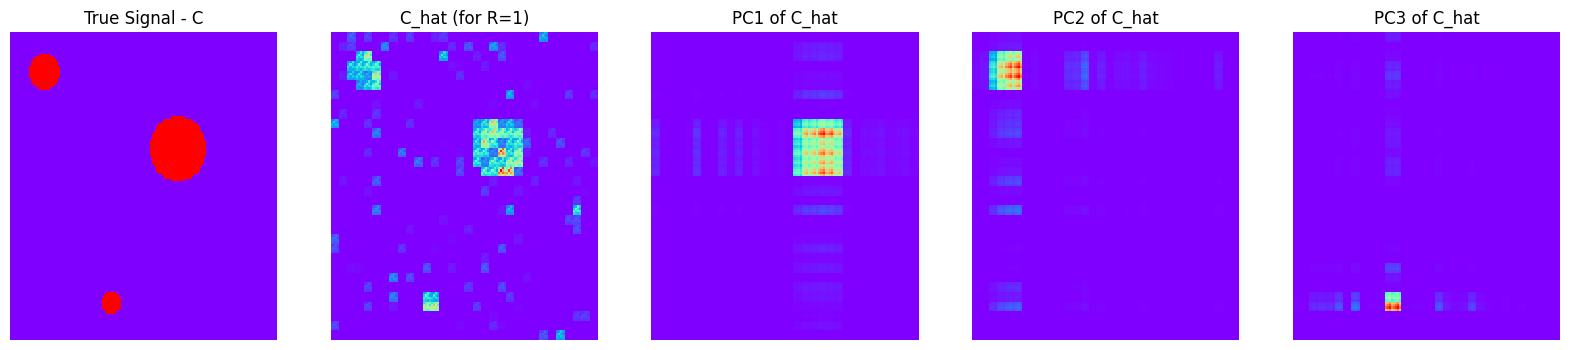

In [7]:
u, s, v = np.linalg.svd(best_fit_model.score['C'])
plt.figure(figsize= (20,4))
ax = plt.subplot(1,5,1)
sns.heatmap(fun_normalization(C_true),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("True Signal - C")
ax = plt.subplot(1,5,2)
sns.heatmap(fun_normalization(best_fit_model.score['C']),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"C_hat (for R=1)")
ax = plt.subplot(1,5,3)
r = 1
sns.heatmap(fun_normalization(u[:,(r-1):r] @ np.diag(s[(r-1):r]) @ v[(r-1):r, :]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"PC{r} of C_hat")
ax = plt.subplot(1,5,4)
r = 2
sns.heatmap(fun_normalization(u[:,(r-1):r] @ np.diag(s[(r-1):r]) @ v[(r-1):r, :]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"PC{r} of C_hat")
ax = plt.subplot(1,5,5)
r = 3
sns.heatmap(fun_normalization(u[:,(r-1):r] @ np.diag(s[(r-1):r]) @ v[(r-1):r, :]),cmap = "rainbow",cbar = False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"PC{r} of C_hat")
plt.show()

In [8]:
y_meta = []
y_meta_scores = []
top_models = [all_models[i] for i in np.array([m.score['MBIC'] for m in all_models]).argsort()[:5]]
for m in top_models:
    y_meta.append(m.predict(X))
    y_meta_scores.append(m.score['MBIC'])
y_meta = np.array(y_meta).T

In [9]:
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
gbtd = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.4,
    min_samples_leaf=8,
)
gbtd.fit(y_meta, Y)

GradientBoostingRegressor(learning_rate=0.01, max_depth=5, min_samples_leaf=8,
                          n_estimators=300, subsample=0.4)

In [10]:
N_new = 1000
np.random.seed(536)
epsilon = np.random.normal(0,1,N_new) * sigma
X_new = np.random.normal(0,1,[N_new, img_shape_m, img_shape_n, img_shape_d]).squeeze()
Y_new = np.random.binomial(1,g.inverse(np.tensordot(X_new, C_true, axes=([1,2], [0,1])) + epsilon))

In [11]:
y_meta_new = []
aucs = []
for m in top_models:
    pred = m.predict(X_new)
    aucs.append(auc(pred,Y_new))
    y_meta_new.append(pred)
y_meta_new = np.array(y_meta_new).T
print(aucs)
print(np.mean(aucs))
print(auc(gbtd.predict(y_meta_new),Y_new))

[0.7944748682967446, 0.691362226003403, 0.7178458424503281, 0.7278462024632887, 0.7836058883078116]
0.7430270055043152
0.7808964943439096


In [12]:
print(auc(np.mean(y_meta_new, axis=1),Y_new))

0.7366285769156904


3D Case

In [13]:
g = Logit()
C_true = np.load("Examples/2-balls.npy")
np.random.seed(539)
## image shape
img_shape_m,img_shape_n,img_shape_d = C_true.shape
## sample size 
N = 1000
## noise level
sigma = 1
epsilon = np.random.normal(0,1,N) * sigma
X = np.random.normal(0,1,[N, img_shape_m, img_shape_n, img_shape_d]).squeeze()
if isinstance(g, Identity):
    Y = g.inverse(np.tensordot(X, C_true, axes=([1,2], [0,1])) + epsilon)
elif isinstance(g, Logit):
    Y = np.random.binomial(1,[g.inverse(np.sum(x*C_true)) for x in X])
else:
    raise NotImplementedError

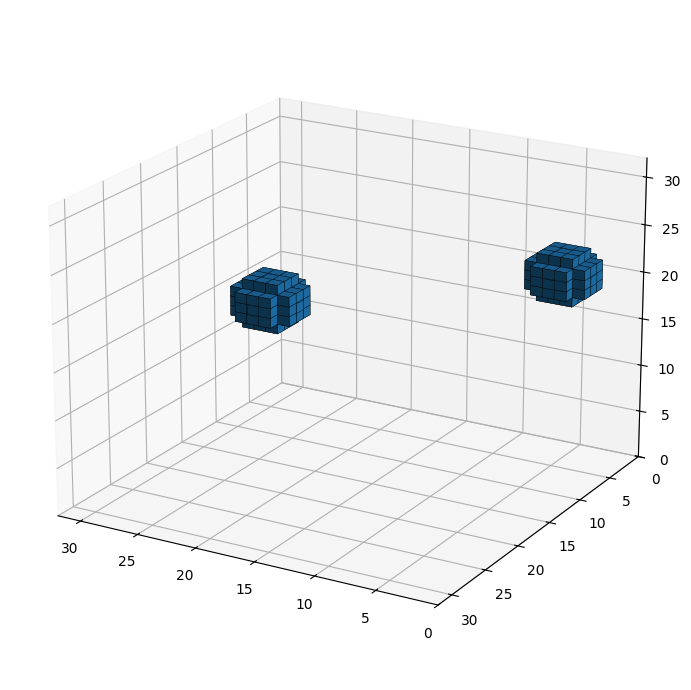

In [14]:
# Create the figure and 3D axes
fig_voxel = plt.figure(figsize=(8, 7))
ax_voxel = fig_voxel.add_subplot(111, projection='3d')

# Plotting only the parts that are "filled" (i.e., > threshold)
ax_voxel.voxels(C_true, edgecolor='k', linewidth=0.25)

# ax_voxel.set_xlabel('X-axis (dim 0)')
# ax_voxel.set_ylabel('Y-axis (dim 1)')
# ax_voxel.set_zlabel('Z-axis (dim 2)')
# ax_voxel.set_title('3D Voxel Plot of C_true (Thresholded)')

# Setting axis limits to match data dimensions for better visualization
ax_voxel.set_xlim([0, C_true.shape[0]])
ax_voxel.set_ylim([0, C_true.shape[1]])
ax_voxel.set_zlim([0, C_true.shape[2]])

# Improve viewing angle
ax_voxel.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()

In [15]:
run = False
if run:
    import matplotlib
    # The data to plot (this is your X[0])
    data_volume = X[0]
    threshold = 0.1 # Show voxels with values greater than this
    filled_voxels = X[0] > threshold
    values_to_map = X[0][filled_voxels]
    if values_to_map.size > 0:
        norm = matplotlib.colors.Normalize(vmin=values_to_map.min(), vmax=values_to_map.max())
    else: # Handle case with no voxels above threshold
        norm = matplotlib.colors.Normalize(vmin=0, vmax=1)

    cmap = plt.cm.viridis
    rgba_colors = np.zeros(X[0].shape + (4,)) # Last dimension is for R,G,B,Alpha
    mapped_colors = cmap(norm(X[0][filled_voxels]))
    base_alpha = 0.6
    mapped_colors[:, 3] = base_alpha # Set alpha channel
    rgba_colors[filled_voxels] = mapped_colors


    # --- Your plotting code, adapted ---
    fig_voxel = plt.figure(figsize=(10, 8)) # Increased figure size
    ax_voxel = fig_voxel.add_subplot(111, projection='3d')

    # Plotting using the boolean 'filled_voxels' and the 'rgba_colors' for facecolors
    ax_voxel.voxels(filled_voxels, facecolors=rgba_colors, edgecolor='k', linewidth=0.15) # Reduced linewidth slightly

    ax_voxel.set_xlabel('X-axis (dim 0)')
    ax_voxel.set_ylabel('Y-axis (dim 1)')
    ax_voxel.set_zlabel('Z-axis (dim 2)')
    ax_voxel.set_title(f'3D Voxel Plot of X[0] (Thresholded, Colored, Transparent)')

    ax_voxel.set_xlim([0, X[0].shape[0]])
    ax_voxel.set_ylim([0, X[0].shape[1]])
    ax_voxel.set_zlim([0, X[0].shape[2]])

    # Improve viewing angle
    ax_voxel.view_init(elev=30, azim=135) # Adjusted viewing angle

    # Add a colorbar to show mapping of values to colors
    # Create a ScalarMappable for the colorbar
    if values_to_map.size > 0 :
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([]) # You need to set_array with an empty list or the values themselves
        cbar = fig_voxel.colorbar(sm, ax=ax_voxel, shrink=0.5, aspect=10, pad=0.1)
        cbar.set_label('Voxel Intensity')


    plt.tight_layout()
    plt.savefig("voxel_plot_colored_transparent.png")
    plt.show()

tra 5 [[0 0 0]
 [0 1 0]
 [0 0 0]]


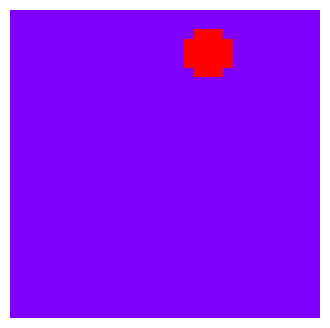

tra 5 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


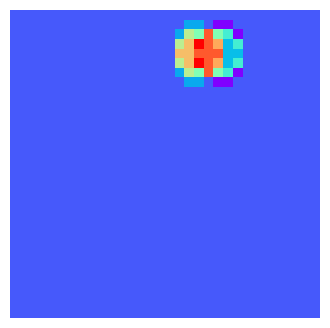

tra 15 [[0 0 0]
 [0 1 0]
 [0 0 0]]


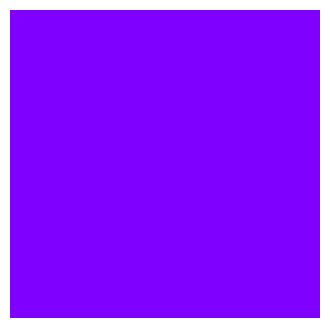

tra 15 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


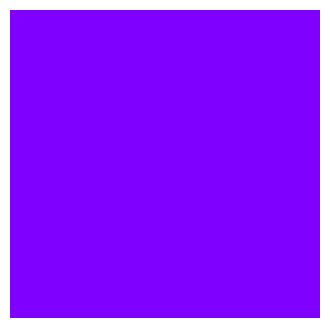

tra 20 [[0 0 0]
 [0 1 0]
 [0 0 0]]


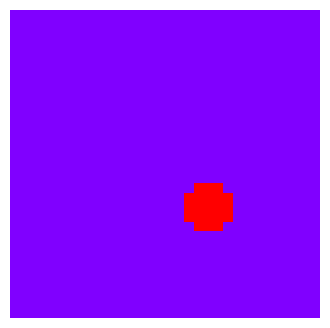

tra 20 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


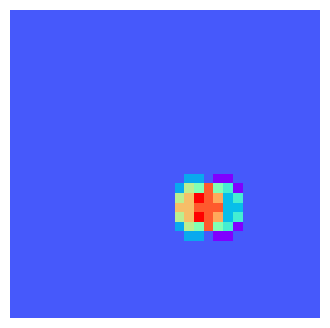

cor 5 [[0 0 0]
 [0 1 0]
 [0 0 0]]


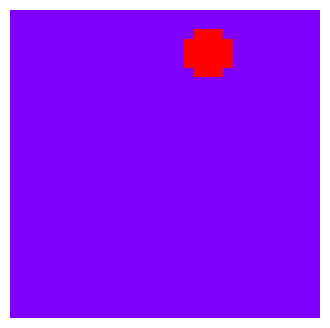

cor 5 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


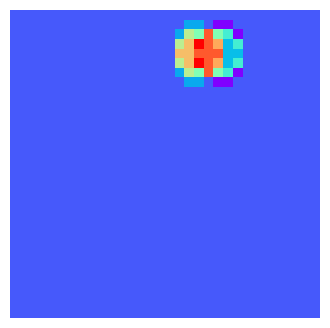

cor 15 [[0 0 0]
 [0 1 0]
 [0 0 0]]


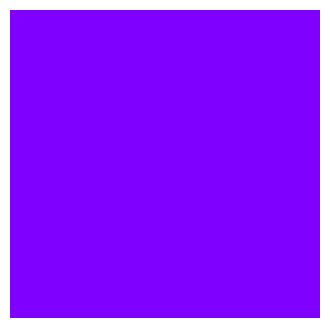

cor 15 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


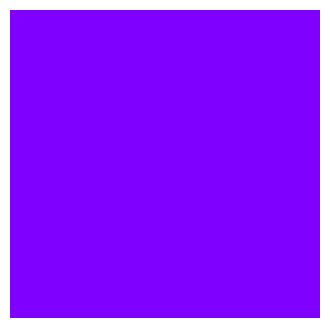

cor 20 [[0 0 0]
 [0 1 0]
 [0 0 0]]


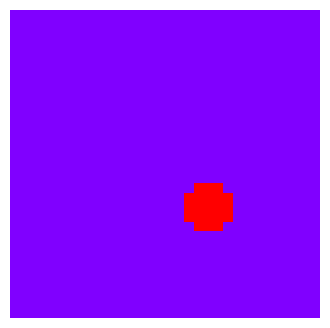

cor 20 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


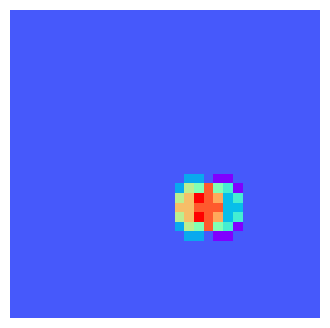

sag 5 [[0 0 0]
 [0 1 0]
 [0 0 0]]


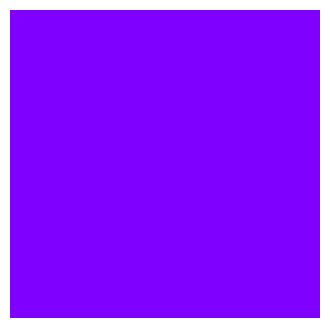

sag 5 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


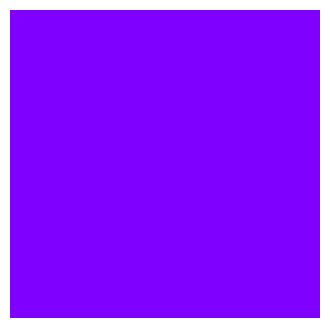

sag 15 [[0 0 0]
 [0 1 0]
 [0 0 0]]


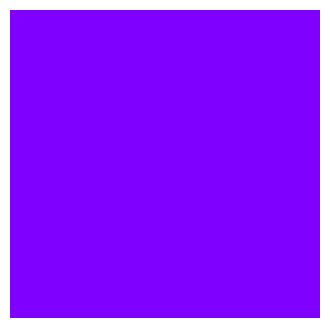

sag 15 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


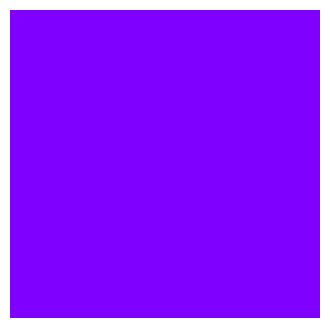

sag 20 [[0 0 0]
 [0 1 0]
 [0 0 0]]


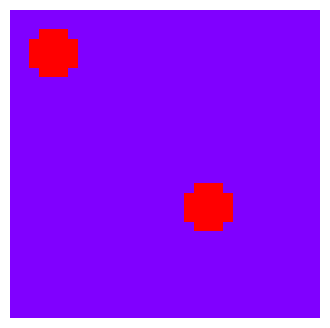

sag 20 [[ 3  0 -3]
 [10  0 10]
 [ 3  0 -3]]


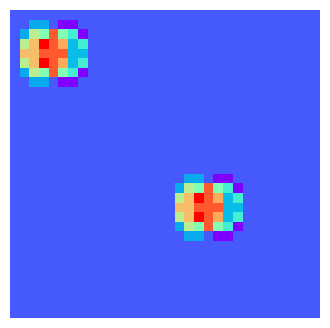

In [16]:
from convolution import convolution
import numpy as np
import pandas as pd
import cv2
from scipy.signal import convolve2d

def resize_image(image, new_height, new_width):
    # Mask of non-zeros
    # initiate as 96x96
    # image = cv2.bilateralFilter(image,9,75,75)
    image = np.array(image)
    original_height, original_width = image.shape
    mask = image != None  # Use a >tolerance for a tolerance defining black border

    # Mask of non-zero rows and columns
    mask_row = mask.any(1)
    mask_col = mask.any(0)

    # First, last indices among the non-zero rows
    sr0, sr1 = mask_row.argmax(), len(mask_row) - mask_row[::-1].argmax()

    # First, last indices among the non-zero columns
    sc0, sc1 = mask_col.argmax(), len(mask_col) - mask_col[::-1].argmax()

    # Finally slice along the rows & cols with the start and stop indices to get
    # cropped image. Slicing helps for an efficient operation.
    cropped_image = image[sr0:sr1, sc0:sc1]

    # Original dimensions
    cropped_height, cropped_width = cropped_image.shape[:2]

    # Create an empty array for the resized image
    resized_image = np.zeros((new_height, new_width), dtype=np.float64)

    # Calculate the ratio of old dimensions to new dimensions
    row_ratio = cropped_height / new_height
    col_ratio = cropped_width / new_width

    # Map each pixel of the resized image to the nearest pixel of the original image
    for i in range(new_height):
        for j in range(new_width):
            # Find the nearest pixel in the original image
            original_i = int(i * row_ratio)
            original_j = int(j * col_ratio)

            # Assign the pixel value
            resized_image[i, j] = cropped_image[original_i, original_j]

    # Return the resized image and cropping boundaries
    return (resized_image, original_height, original_width, sr0, sr1, sc0, sc1)

def invert_resize_image(resized_image, original_height, original_width, sr0, sr1, sc0, sc1):
    # Calculate the height and width of the cropped image
    cropped_height = sr1 - sr0
    cropped_width = sc1 - sc0

    # Create an empty array for the cropped image
    cropped_image = np.zeros((cropped_height, cropped_width), dtype=np.float64)
    original_image = np.zeros((original_height, original_width), dtype=np.float64)

    # Calculate the ratio of new dimensions to old dimensions
    row_ratio = cropped_height / resized_image.shape[0]
    col_ratio = cropped_width / resized_image.shape[1]

    # Map each pixel of the cropped image to the nearest pixel of the resized image
    for i in range(cropped_height):
        for j in range(cropped_width):
            # Find the nearest pixel in the resized image
            resized_i = int(i / row_ratio)
            resized_j = int(j / col_ratio)

            # Assign the pixel value
            cropped_image[i, j] = resized_image[resized_i, resized_j]

    # Place the cropped image back into its original position
    original_image[sr0:sr1, sc0:sc1] = cropped_image

    return original_image

def extract_and_resize(X, slice, instance, size, kernel=None):
    slice_options = ['tra','cor','sag']
    assert slice in slice_options, f"slice: {slice}, provided is not an available option {slice_options}"
    if slice == 'tra': 
        X_ret = X[instance,:,:]
    if slice == 'cor':
        X_ret = X[:,instance,:]
    if slice == 'sag':
        X_ret = X[:,:,instance]
    res = resize_image(X_ret,*size)
    if kernel is not None:
        res = convolve2d(res[0], kernel, mode='same')
    return (res, None)

def extract_slice(X, slice, number=None):
    return (X[slice], None)

identity_kernel = np.array([[0, 0, 0],
                              [0, 1, 0],
                              [0, 0, 0]])
scharr_horizontal_kernel = np.array([[3, 0, -3],
                              [10, 0, 10],
                              [3, 0, -3]])
scharr_vertical_kernel = np.array([[3, 10, 3],
                              [0, 0, 0],
                              [-3, -10, -3]])
laplacian_kernel = np.array([[0, -1, 0],
                              [-1, 4, -1],
                              [0, -1, 0]])
kernel_list = [identity_kernel, scharr_horizontal_kernel, scharr_vertical_kernel, laplacian_kernel]

import seaborn as sns
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range
for s in ['tra','cor','sag']:
    for i in [5,15,20]:
            for k in kernel_list[:2]:
                L = convolution(extract_and_resize, {'slice': s, 'instance': i, 'size': (32,32), 'kernel': k}, extract_and_resize)
                out = L.convolve(C_true)
                print(s,i,k)

                plt.figure(figsize= (4,4))
                ax = plt.subplot(1,1,1)
                sns.heatmap(out,cmap = "rainbow",cbar = False)
                ax.set_xticks([])
                ax.set_yticks([])
                plt.show()

In [17]:
def plot_model_single(model_results, X, y, cutoff_point=1E-9, pcs=None):
    # X = model_results.L.convolve(X)
    cmap = plt.cm.gray
    cmap = cmap(np.arange(cmap.N))
    cmap[0, -1] = 0 # first color transparency
    cmap[1:, -1] = 0.5 # alpha value
    custom_cmap = mcolors.ListedColormap(cmap)
    C_hat = model_results.C
    u, s, v = np.linalg.svd(C_hat)
    if pcs is not None:
        C_hat = u[:,(pcs-1):pcs] @ np.diag(s[(pcs-1):pcs]) @ v[(pcs-1):pcs, :]

    plt.figure(figsize= (4,4))
    fig = plt.subplot(1,1,1)
    # Demented Brain
    plt.subplot(1, 1, 1)
    sns.heatmap(model_results.L.convolve(X[np.argmin(y[~np.equal(y, None)])]), cmap='viridis', cbar=False)
    sns.heatmap(np.abs(C_hat)>=cutoff_point, cmap=custom_cmap, cbar=False)  # Assuming grayscale or using first channel for RGB
    fig.set_xticks([])
    fig.set_yticks([])

    plt.show()

In [18]:
kf = KFold(5,shuffle=True)
sample = np.array(range(len(Y)))
test_k = [idx[1] for idx in list(kf.split(sample))]
train_k = [np.setdiff1d(sample, k) for k in test_k]

In [ ]:
folds = []
for i in range(5):
    # TODO: Include 3d in the model to determine best slice to use
    p_list = [[8,8],[16,16],[8,16],[16,8]]
    lam = [2**i for i in range(2,4)]
    params = {
        'p': [[16,16]],
        'lama': lam,
        'lamb': 0,
        'g': Logit(),
        'R': 1,
        'max_iter': 5
    }
    model_parameters = []
    for s in ['tra','cor','sag']:
        for inst in [5,15,20]:
                for k in kernel_list:
                    model_parameters.append({'L': convolution(extract_and_resize, {'slice': s, 'instance': inst, 'size': (32,32), 'kernel': k}, extract_and_resize)})
    
    ensemble_model = EnsembleCSKPD()
    ensemble_model.fit(X[train_k[i]], Y[train_k[i]], model_parameters=model_parameters, common_parameters=params)
    folds.append(ensemble_model)

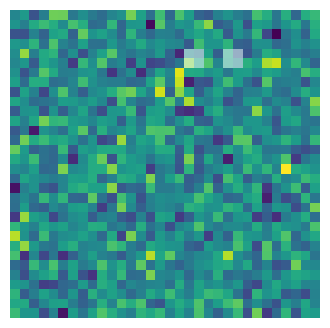

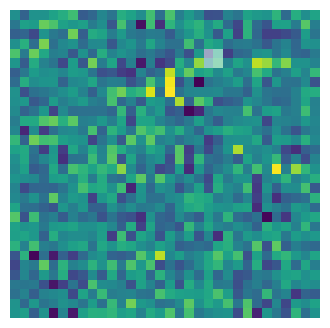

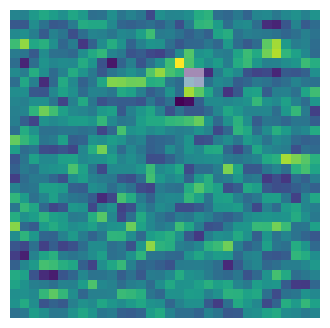

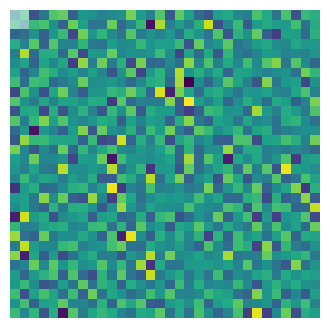

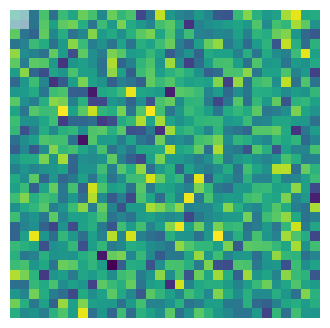

In [ ]:
first5 = 0
for i, m in enumerate(folds[0].models):
    if first5 < 5:
        plot_model_single(m, X[test_k[0]], Y[test_k[0]], cutoff_point=1E-5)
        first5 += 1

In [ ]:
aucs = []
for i, f in enumerate(folds):
    y_hat = f.predict(X[test_k[i]])
    aucs.append(auc(y_hat, Y[test_k[i]]))
auc_score = {}
y_hats = {}
for i, f in enumerate(folds):
    for j, e in enumerate(f.models):
        try:
            y_h = np.round(e.predict(X[test_k[i]]),0)
            auc_score[(i,j)] = auc(y_h, Y[test_k[i]])
            y_hats[(i,j)] = list(y_h)
        except:
            pass
for k in range(6):
    score = np.array([s for (i,j), s in auc_score.items() if j == k])
    print(f"Model {k}: Average ({np.average(score)}), Best ({np.max(score)})")
print(f"Ensemble: Average ({np.mean(aucs)}), Best ({np.max(aucs)})")

Model 0: Average (0.5257181872570678), Best (0.5513850272886417)
Model 1: Average (0.5448675801214664), Best (0.5742753623188407)
Model 2: Average (0.5558808147393359), Best (0.5885186672019269)
Model 3: Average (0.5023215930265044), Best (0.5232323232323233)
Model 4: Average (0.5106813457542348), Best (0.5422242971262579)
Model 5: Average (0.5001886242872046), Best (0.5319148936170213)
Ensemble: Average (0.6510558762930412), Best (0.6852538358562454)


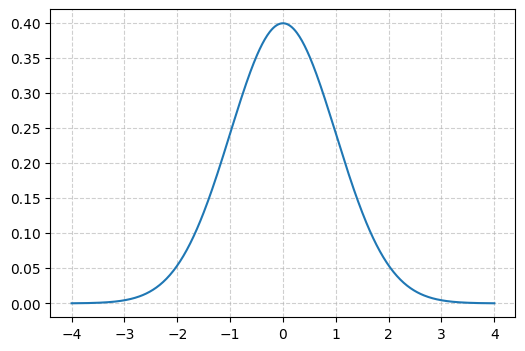

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for the normal distribution
mu, sigma = 0, 1   # mean and standard deviation

# Generate x values
x = np.linspace(-4, 4, 500)

# Probability density function (PDF)
y = norm.pdf(x, mu, sigma)

# Plot
plt.figure(figsize=(6,4))
plt.plot(x, y)
# plt.title("Probability Distribution Curve")
# plt.xlabel(r'$\hat{y}$')
# plt.ylabel("Probability Density")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
